In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import itertools
from scipy.integrate import ode
from scipy.optimize import minimize 



In [3]:
# Load and clean up data
data = pd.read_csv("Folder1-Flow_Cytometry_Data/20250312_GBR_Pre-Post-Mixing_Default Unmixed Worksheet.csv", index_col=0)
data = data[[
    "All Events Count", "Cell Population Count", "Green+ Count", "mCYRFP1+ Count", "Blue+ Count",
    "GFP-BFP+ Count", "GFP-RFP+ Count", "BFP-RFP+ Count", "All+ Count"
]]
data.columns = ["Events", "Cell Population", "GFP+", "RFP+", "BFP+", "GFP_BFP+", "GFP_RFP+", "BFP_RFP+", "All+"]
data = data[["Reference" not in x for x in data.index]]

# Constants
PLASMID_SIZES = {
    "GFP": 4966,
    "RFP": 4902,
    "BFP": 4947,
}
TOTAL_DNA_NG = 100
PLATED_CELLS = 5e4

# Function to calculate plasmid copies per cell in media
def calculate_plasmid_copies_per_cell(mass_ng, plasmid_bp):
    AVOGADRO = 6.022e23
    bp_weight = 660  # g/mol per bp
    mass_g = mass_ng * 1e-9
    moles = mass_g / (plasmid_bp * bp_weight)
    return (moles * AVOGADRO) / PLATED_CELLS

# Count how many plasmids are present in sample name
def count_plasmids_in_name(name):
    if "All" in name:
        return 3
    return sum(tag in name for tag in PLASMID_SIZES)

def compute_plasmids_per_cell(row, color):
    name = row.name
    # Only compute if the color is present or if it's an 'All' condition
    if color not in name and "All" not in name:
        return 0
    num_plasmids = count_plasmids_in_name(name)
    if num_plasmids == 0:
        return 0
    dna_per_plasmid = TOTAL_DNA_NG / num_plasmids
    plasmid_bp = PLASMID_SIZES[color]
    return calculate_plasmid_copies_per_cell(dna_per_plasmid, plasmid_bp)

# Add columns for plasmids per cell (in media)
for color in ["GFP", "RFP", "BFP"]:
    data[f"# {color} Plasmids per cell"] = data.apply(lambda row: compute_plasmids_per_cell(row, color), axis=1)

# Normalize expression markers to probabilities
for col in ["GFP+", "RFP+", "BFP+", "GFP_BFP+", "GFP_RFP+", "BFP_RFP+", "All+"]:
    data[col] = data[col] / data["Cell Population"]

# Clean up
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)
#data




In [4]:
## this function is taken from the UQ-Bio 2024 Summer School Github https://github.com/MunskyGroup/uqbio2024

def build_inf_gen(S, W, states, pars, t=0):
    """ Build the infinitesimal generator matrix for a continuous time Markov chain.
    S: Stoichiometry matrix
    W: Propensity vector function
    states: list of states in FSP approximation
    t: time
    """
    
    # Determie the number of species, states and reactions
    nSpecies, nStates = states.shape
    nReactions = S.shape[1]
    
    # Compute the propensity functions for all states.
    propensities = W(states, t, pars)

    # Step through each reaction
    infGens = []
    infGen = np.zeros((nStates+1,nStates+1))
    sink = np.zeros(nStates)
    for mu in range(nReactions):
        # Compute flow of probability out of all states due to reaction mu
        infGens.append(-np.diag(propensities[mu,:]))
        
        for i in range(nStates):
            # Compute the states after the reaction mu
            newState = (states[:,i] + S[:,mu]).reshape(-1,1) 

            # Check if the state is non-negative
            if np.all(newState >= 0):
                # Find the index of the state
                try:
                    j = np.where((states == newState).all(axis=0))[0][0]
                    infGens[mu][j,i] += propensities[mu,i]

                except:
                    sink[i] += propensities[mu,i]
        # Add the current reaction to the infinitesimal generator
        infGen[:nStates,:nStates] += infGens[mu]
    
    # Add the sink as the final row of the infinitesimal generator
    infGen[nStates,:nStates] = sink

    return infGens, sink, infGen

In [5]:
ctrl_data = data[["pUC19" in x for x in data.index]].iloc[:,2:9]
GFP_data = data[["GFP" in x and "RFP" not in x and "BFP" not in x for x in data.index]].iloc[:,2:9]
RFP_data = data[["RFP" in x and "GFP" not in x and "BFP" not in x for x in data.index]].iloc[:,2:9]
BFP_data = data[["BFP" in x and "GFP" not in x and "RFP" not in x for x in data.index]].iloc[:,2:9]
GFP_BFP_postdata = data[["BFP" in x and "GFP" in x and "RFP" not in x and "POST" in x for x in data.index]].iloc[:,2:9]
GFP_BFP_predata = data[["BFP" in x and "GFP" in x and "RFP" not in x and "POST" not in x for x in data.index]].iloc[:,2:9]
GFP_RFP_postdata = data[["RFP" in x and "GFP" in x and "BFP" not in x and "POST" in x for x in data.index]].iloc[:,2:9]
GFP_RFP_predata = data[["RFP" in x and "GFP" in x and "BFP" not in x and "POST" not in x for x in data.index]].iloc[:,2:9]
BFP_RFP_postdata = data[["RFP" in x and "BFP" in x and "GFP" not in x and "POST" in x for x in data.index]].iloc[:,2:9]
BFP_RFP_predata = data[["RFP" in x and "BFP" in x and "GFP" not in x and "POST" not in x for x in data.index]].iloc[:,2:9]
all_postdata = data[["All" in x and "POST" in x for x in data.index]].iloc[:,2:9]
all_predata = data[["All" in x  and "POST" not in x for x in data.index]].iloc[:,2:9]




In [6]:
x0_list = [np.array([367468.5, 0, 0, 0, 0, 0]),  # GFP only
           np.array([0, 0, 372266.1, 0, 0, 0]),  # RFP only
           np.array([0, 0, 0, 0, 368879.8, 0]),  # BFP only
           np.array([183734.2, 0, 0, 0, 184439.9, 0]),  # GFP + BFP
           np.array([183734.2, 0, 186133.1, 0, 0, 0]),  # GFP + RFP
           np.array([0, 0, 186133.1, 0, 184439.9, 0]),  # BFP + RFP
           np.array([122489.5, 0, 124088.7, 0, 122959.9, 0])]# All three]

# Pre-condition data (no POST in index)
data_pre = [GFP_data.values,
            RFP_data.values,
            BFP_data.values,
            GFP_BFP_predata.values,
            GFP_RFP_predata.values,
            BFP_RFP_predata.values,
            all_predata.values]

# Post-condition data (with POST in index)
data_post =[GFP_data.values,
    RFP_data.values,
    BFP_data.values,
    GFP_BFP_postdata.values,
    GFP_RFP_postdata.values,
    BFP_RFP_postdata.values,
    all_postdata.values]



In [7]:
fits = pd.read_csv("Folder2-Model_Parameter_Fits/all_fit_output.csv", index_col = 0)
estimate = fits.iloc[0,2]


In [8]:

def experiment_1(x0, params):
    max_plasmids = 8
    
    S = np.array([
        [1, 0, 0, 1, 1, 0, 1],  # GFP+
        [0, 1, 0, 1, 0, 1, 1],  # RFP+
        [0, 0, 1, 0, 1, 1, 1],  # BFP+
    ])

    states = np.array(list(itertools.product(range(max_plasmids + 1), repeat=3))).T

    G, R, B = x0[0], x0[2], x0[4]
    x0 = x0[::2]
    
    vesicle_rate = params[0]
    single_1 = vesicle_rate * G
    single_2 = vesicle_rate * R
    single_3 = vesicle_rate * B

    double_1= 0
    double_2= 0
    double_3= 0
    triple= 0
    # Clamp to zero (no negative rates)
    pars = {
        'kcell_entry1': np.max([0, single_1]),
        'kcell_entry2': np.max([0, single_2]),
        'kcell_entry3': np.max([0, single_3]),
        'kcell_entry4': np.max([0, double_1]),
        'kcell_entry5': np.max([0, double_2]),
        'kcell_entry6': np.max([0, double_3]),
        'kcell_entry7': np.max([0, triple])
    }
    #print(pars)
    def W_linear(states, t, pars):
        nStates = states.shape[1]
        W = np.zeros((7, nStates))
        W[0, :] = pars['kcell_entry1']
        W[1, :] = pars['kcell_entry2']
        W[2, :] = pars['kcell_entry3']
        W[3, :] = pars['kcell_entry4']
        W[4, :] = pars['kcell_entry5']
        W[5, :] = pars['kcell_entry6']
        W[6, :] = pars['kcell_entry7']
        return W


    infGens, sink, infGenTotal = build_inf_gen(S, W_linear, states, pars)

    x0_state = np.zeros(3, dtype=int)
    idx0 = np.where([(states[:, i] == x0_state).all() for i in range(states.shape[1])])[0]
    P0 = np.zeros(infGenTotal.shape[1])
    P0[idx0] = 1

    tspan = np.linspace(0, 4, 100)
    def FSPrhs(t, P): return infGenTotal @ P
    def jac(t, P): return infGenTotal

    solver = ode(FSPrhs, jac=jac).set_integrator('vode', method='bdf')
    solver.set_initial_value(P0)

    P_approach1 = np.zeros((len(tspan), len(P0)))
    P_approach1[0, :] = P0
    for i in range(1, len(tspan)):
        P_approach1[i, :] = solver.integrate(tspan[i])

    P_final = P_approach1[-1, :]

    joint_probs = np.array([
        np.sum(P_final[:-1][(states[0, :] > 0)]),  # GFP+
        np.sum(P_final[:-1][(states[1, :] > 0)]),  # RFP+
        np.sum(P_final[:-1][(states[2, :] > 0)]),  # BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[2, :] > 0)]),  # GFP_BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[1, :] > 0)]),  # GFP_RFP+
        np.sum(P_final[:-1][(states[1, :] > 0) * (states[2, :] > 0)]),  # RFP_BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[1, :] > 0) * (states[2, :] > 0)])  # All+
    ])


    #print(joint_probs)
    return joint_probs
# x0_list is your 7 plasmid conditions
#model_post_preds = np.array([experiment_predict(x0, res_post.x) for x0 in x0_list])


In [9]:

def experiment_2(x0, params):
    max_plasmids = 8
    
    S = np.array([
        [1, 0, 0, 1, 1, 0, 1],  # GFP+
        [0, 1, 0, 1, 0, 1, 1],  # RFP+
        [0, 0, 1, 0, 1, 1, 1],  # BFP+
    ])

    states = np.array(list(itertools.product(range(max_plasmids + 1), repeat=3))).T

    G, R, B = x0[0], x0[2], x0[4]
    x0 = x0[::2]
    
    vesicle_rate = params[0]
    G_rate = vesicle_rate * G
    R_rate = vesicle_rate * R
    B_rate = vesicle_rate * B
    if G > 0 and B > 0 and R > 0:
        double_1= ( (G_rate + R_rate)/2 ) * (2/6)
        double_2= ( (G_rate + B_rate)/2 ) * (2/6)
        double_3= ( (B_rate + R_rate)/2 ) * (2/6)
        triple= ( (G_rate + R_rate + B_rate)/3 ) * (1/6)
        single_1 = G_rate - double_1 - double_2 - triple
        single_2 = R_rate - double_1 - double_3 - triple
        single_3 = B_rate - double_3 - double_2 - triple
    elif G > 0 and B > 0 and R < 1e-2:
        double_1= 0
        double_2= ((G_rate + B_rate)/2 ) * (2/3)
        double_3= 0
        triple= 0
        single_1 = G_rate - double_1 - double_2 - triple
        single_2 = R_rate - double_1 - double_3 - triple
        single_3 = B_rate - double_3 - double_2 - triple        
    elif G > 0 and R > 0 and B < 1e-2:
        double_1= ((G_rate + R_rate)/2 ) * (2/3)
        double_2= 0
        double_3= 0
        triple= 0
        single_1 = G_rate - double_1 - double_2 - triple
        single_2 = R_rate - double_1 - double_3 - triple
        single_3 = B_rate - double_3 - double_2 - triple    
    elif B > 0 and R > 0 and G < 1e-2:
        double_1= 0
        double_2= 0
        double_3= ((R_rate + B_rate)/2 ) * (2/3)
        triple= 0
        single_1 = G_rate - double_1 - double_2 - triple
        single_2 = R_rate - double_1 - double_3 - triple
        single_3 = B_rate - double_3 - double_2 - triple    
    else:
        double_1= 0
        double_2= 0
        double_3= 0
        triple= 0
        
        single_1 = G_rate
        single_2 = R_rate
        single_3 = B_rate
    # Clamp to zero (no negative rates)
    pars = {
        'kcell_entry1': np.max([0, single_1]),
        'kcell_entry2': np.max([0, single_2]),
        'kcell_entry3': np.max([0, single_3]),
        'kcell_entry4': np.max([0, double_1]),
        'kcell_entry5': np.max([0, double_2]),
        'kcell_entry6': np.max([0, double_3]),
        'kcell_entry7': np.max([0, triple])
    }
    def W_linear(states, t, pars):
        nStates = states.shape[1]
        W = np.zeros((7, nStates))
        W[0, :] = pars['kcell_entry1']
        W[1, :] = pars['kcell_entry2']
        W[2, :] = pars['kcell_entry3']
        W[3, :] = pars['kcell_entry4']
        W[4, :] = pars['kcell_entry5']
        W[5, :] = pars['kcell_entry6']
        W[6, :] = pars['kcell_entry7']
        return W


    infGens, sink, infGenTotal = build_inf_gen(S, W_linear, states, pars)

    x0_state = np.zeros(3, dtype=int)
    idx0 = np.where([(states[:, i] == x0_state).all() for i in range(states.shape[1])])[0]
    P0 = np.zeros(infGenTotal.shape[1])
    P0[idx0] = 1

    tspan = np.linspace(0, 4, 100)
    def FSPrhs(t, P): return infGenTotal @ P
    def jac(t, P): return infGenTotal

    solver = ode(FSPrhs, jac=jac).set_integrator('vode', method='bdf')
    solver.set_initial_value(P0)

    P_approach1 = np.zeros((len(tspan), len(P0)))
    P_approach1[0, :] = P0
    for i in range(1, len(tspan)):
        P_approach1[i, :] = solver.integrate(tspan[i])

    P_final = P_approach1[-1, :]

    joint_probs = np.array([
        np.sum(P_final[:-1][(states[0, :] > 0)]),  # GFP+
        np.sum(P_final[:-1][(states[1, :] > 0)]),  # RFP+
        np.sum(P_final[:-1][(states[2, :] > 0)]),  # BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[2, :] > 0)]),  # GFP_BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[1, :] > 0)]),  # GFP_RFP+
        np.sum(P_final[:-1][(states[1, :] > 0) * (states[2, :] > 0)]),  # RFP_BFP+
        np.sum(P_final[:-1][(states[0, :] > 0) * (states[1, :] > 0) * (states[2, :] > 0)])  # All+
    ])


    return joint_probs #single_1, double_1, triple
# x0_list is your 7 plasmid conditions
#model_post_preds = np.array([experiment_predict(x0, res_post.x) for x0 in x0_list])


In [10]:
from scipy.stats import sem

def get_mean_and_ci(df):
    mean = df.mean(axis=0).values
    ci = 1.96 * sem(df.values, axis=0)
    return mean, ci

group_data_pre = [
    GFP_data,
    RFP_data,
    BFP_data,
    GFP_BFP_predata,
    GFP_RFP_predata,
    BFP_RFP_predata,
    all_predata
]

data_pre_avg, data_pre_ci = zip(*[get_mean_and_ci(df) for df in group_data_pre])
data_pre_avg = np.vstack(data_pre_avg)
data_pre_ci = np.vstack(data_pre_ci)


group_data_post = [
    GFP_data,
    RFP_data,
    BFP_data,
    GFP_BFP_postdata,
    GFP_RFP_postdata,
    BFP_RFP_postdata,
    all_postdata
]

data_post_avg, data_post_ci = zip(*[get_mean_and_ci(df) for df in group_data_post])
data_post_avg = np.vstack(data_post_avg)
data_post_ci = np.vstack(data_post_ci)






In [11]:
model_1_preds = np.array([experiment_1(x0, [estimate]) for x0 in x0_list])
model_2_preds = np.array([experiment_2(x0, [estimate]) for x0 in x0_list])





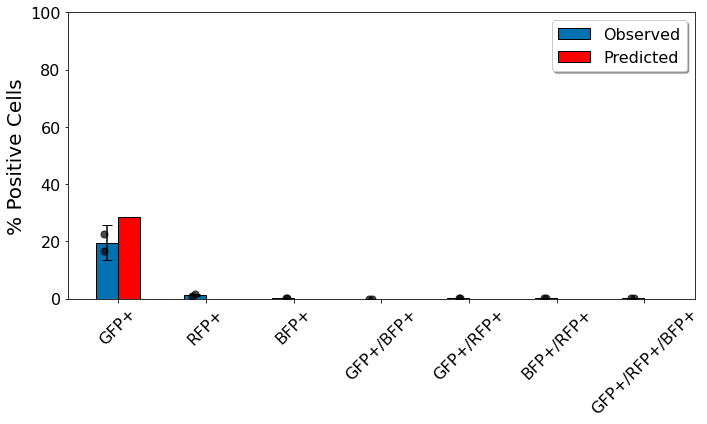

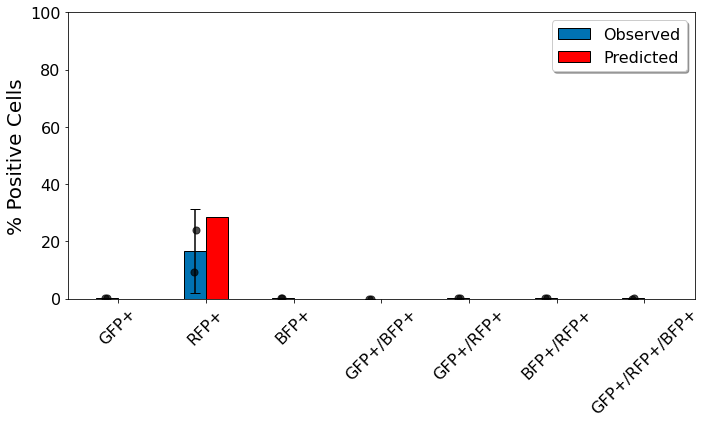

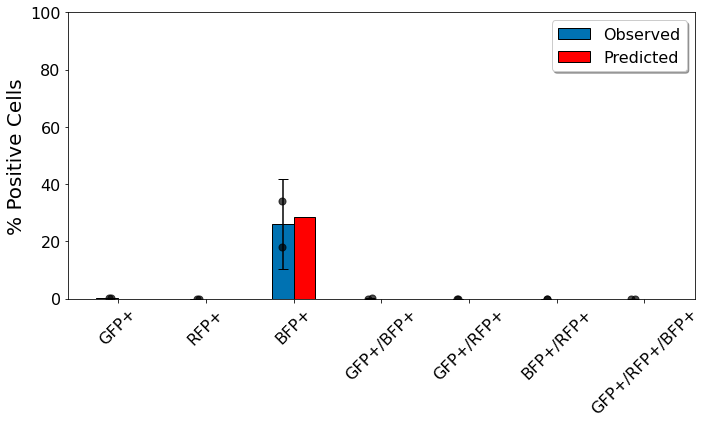

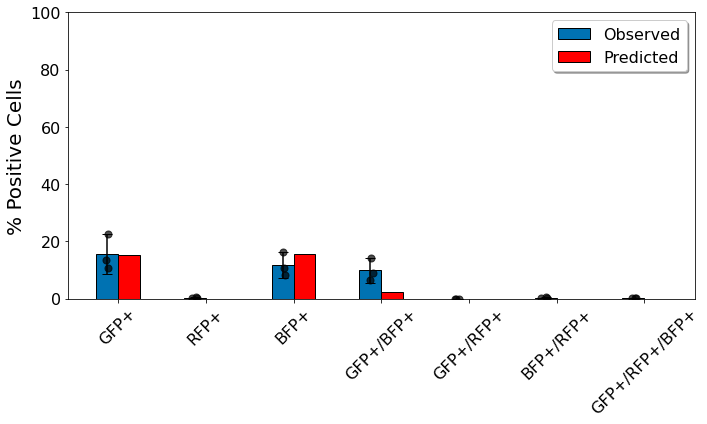

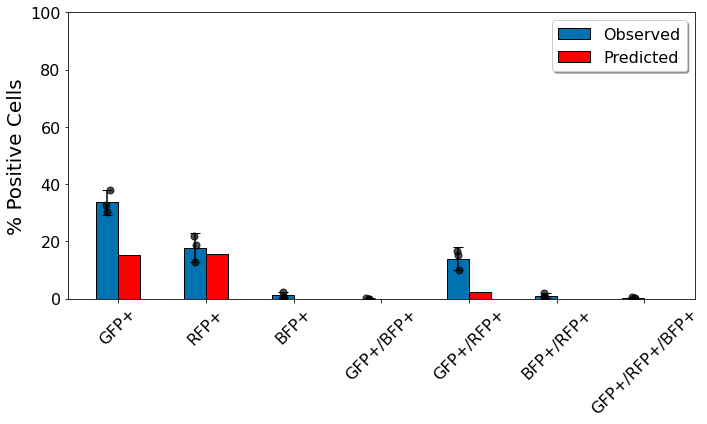

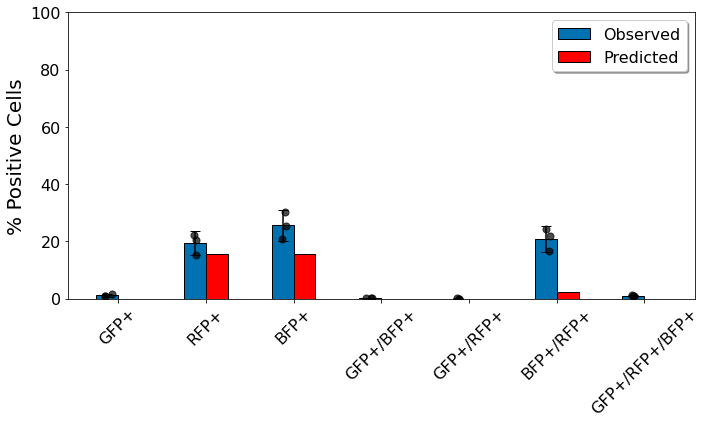

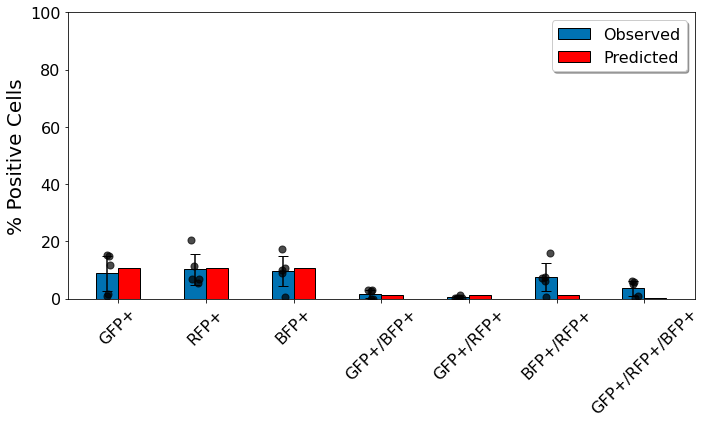

In [12]:
labels = ["GFP+", "RFP+", "BFP+", "GFP+/BFP+", "GFP+/RFP+", "BFP+/RFP+", "GFP+/RFP+/BFP+"]
x = np.arange(len(labels))
width = 0.25

for i in range(len(x0_list)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Bars
    ax.bar(x - width/2, data_pre_avg[i] * 100, width=width, yerr=data_pre_ci[i] * 100, color='#0072B2', edgecolor='black', label='Observed', capsize=5)
    ax.bar(x + width/2, model_1_preds[i] * 100, width=width, color='red', edgecolor='black', label='Predicted')
    
    # Scatter individual observations for the "Observed" data
    for j in range(len(x)):
        x_jitter = np.random.normal(loc=x[j] - width/2, scale=0.02, size=len(group_data_pre[i].iloc[:,j]))
        ax.scatter(x_jitter, group_data_pre[i].iloc[:,j] * 100, color='black', alpha=0.7, s=50, zorder=10)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, rotation=45)
    ax.set_ylabel('% Positive Cells', fontsize=20)
    #ax.set_xlabel('Marker', fontsize=20)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    #ax.set_title(f'Condition {i+1}', fontsize=22)
    ax.legend(loc='best', fontsize=16, frameon=True, shadow=True)
    
    plt.tight_layout()
    if i in [6]:
        plt.savefig(f"Figures/Fig4/Mod1_Pre/datavpreds_mod1_pre_{i}.svg")
    plt.savefig(f"Figures/FigS3/Mod1_Pre/datavpreds_mod1_pre_{i}.svg")
    plt.show()


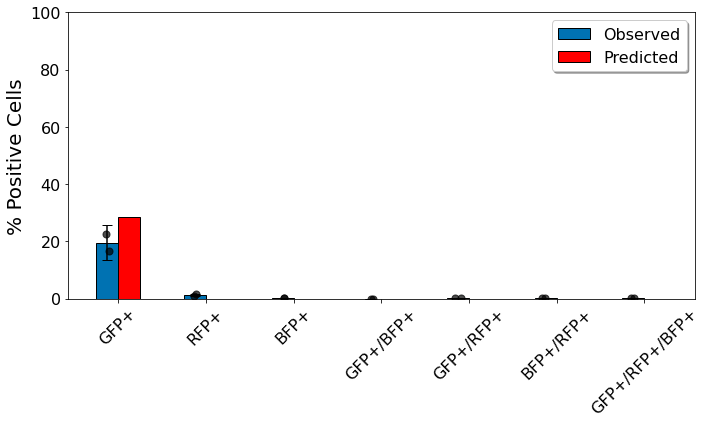

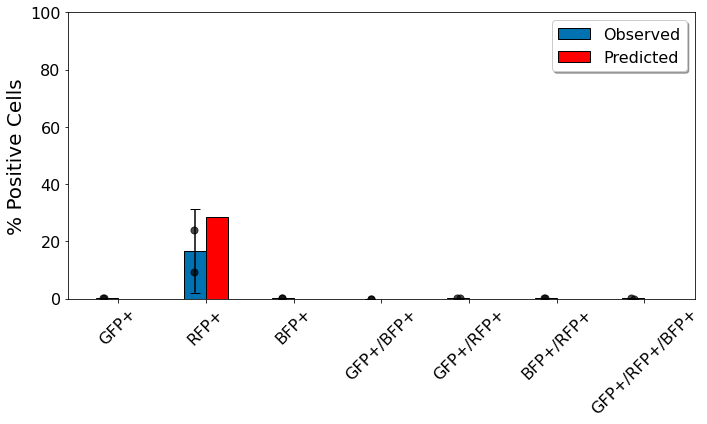

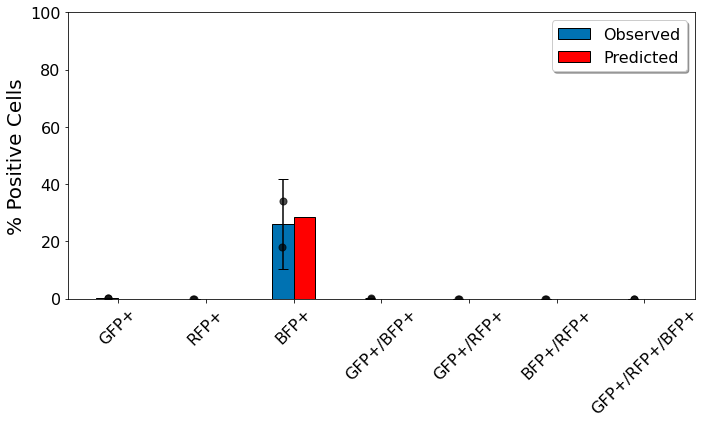

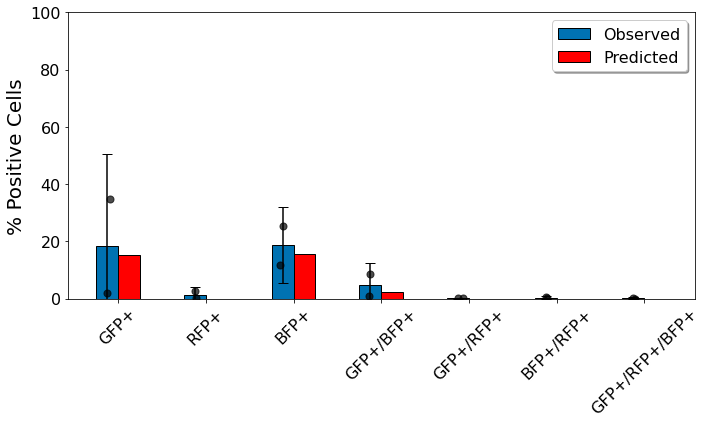

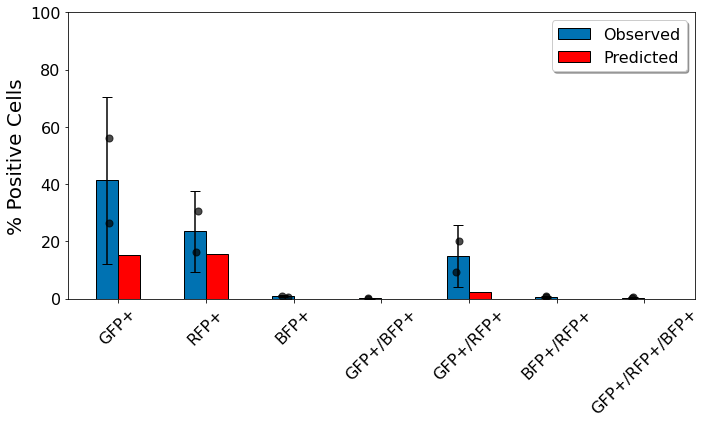

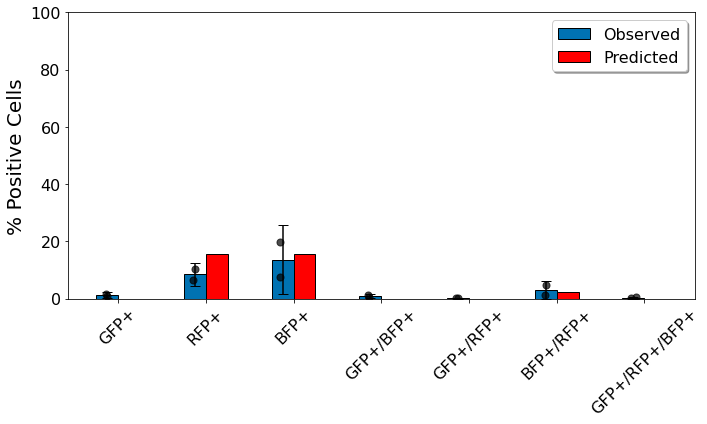

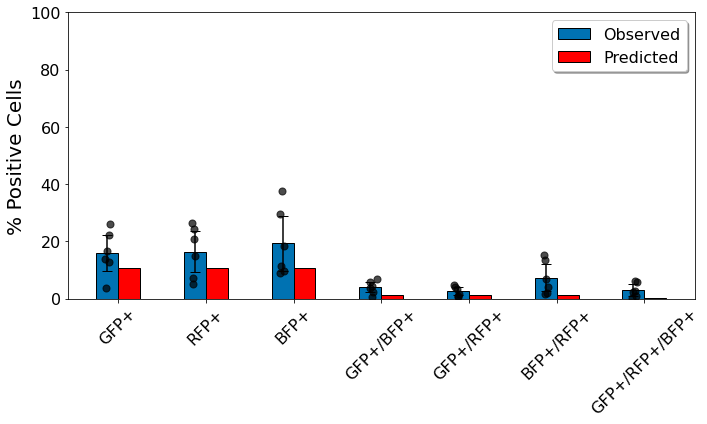

In [13]:
labels = ["GFP+", "RFP+", "BFP+", "GFP+/BFP+", "GFP+/RFP+", "BFP+/RFP+", "GFP+/RFP+/BFP+"]
x = np.arange(len(labels))
width = 0.25

for i in range(len(x0_list)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Bars
    ax.bar(x - width/2, data_post_avg[i]* 100, width=width, yerr=data_post_ci[i]* 100, color='#0072B2', edgecolor='black', label='Observed', capsize=5)
    ax.bar(x + width/2, model_1_preds[i]* 100, width=width, color='red', edgecolor='black', label='Predicted')
    
    # Scatter individual observations for the "Observed" data
    for j in range(len(x)):
        x_jitter = np.random.normal(loc=x[j] - width/2, scale=0.02, size=len(group_data_post[i].iloc[:,j]))
        ax.scatter(x_jitter, group_data_post[i].iloc[:,j]* 100, color='black', alpha=0.7, s=50, zorder=10)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, rotation=45)
    ax.set_ylabel('% Positive Cells', fontsize=20)
    #ax.set_xlabel('Marker', fontsize=20)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    #ax.set_title(f'Condition {i+1}', fontsize=22)
    ax.legend(loc='best', fontsize=16, frameon=True, shadow=True)
    
    plt.tight_layout()
    
    if i in [6]:
        plt.savefig(f"Figures/Fig4/Mod1_Post/datavpreds_mod1_post_{i}.svg")
    plt.savefig(f"Figures/FigS2/Mod1_Post/datavpreds_mod1_post_{i}.svg")
    plt.show()


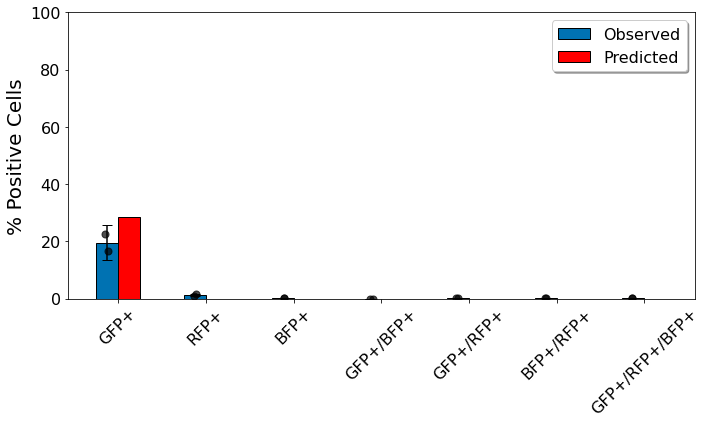

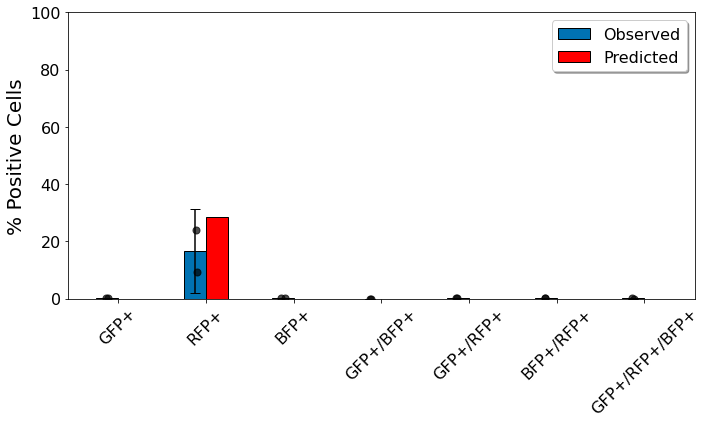

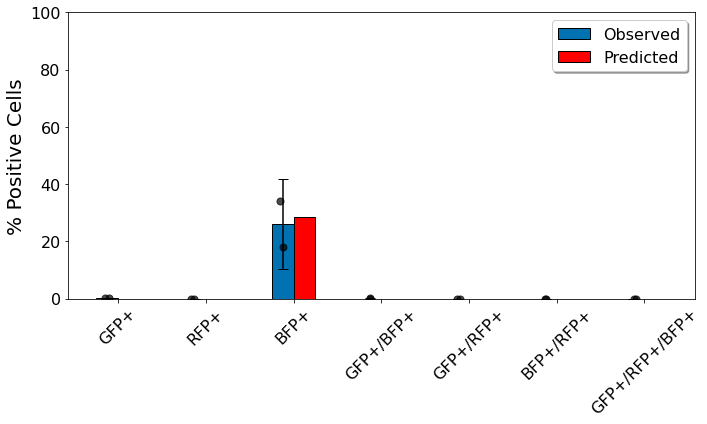

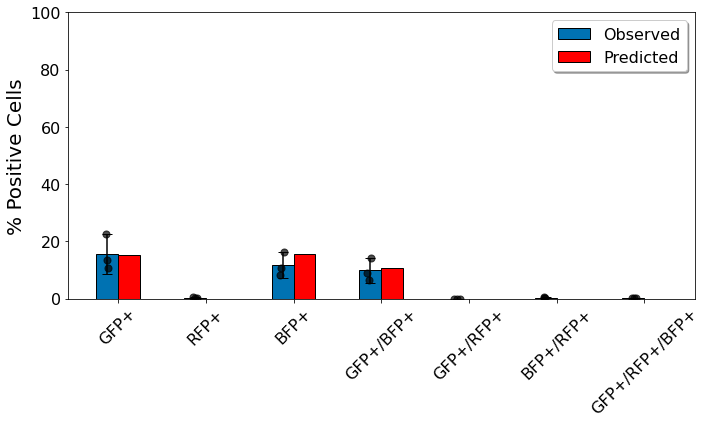

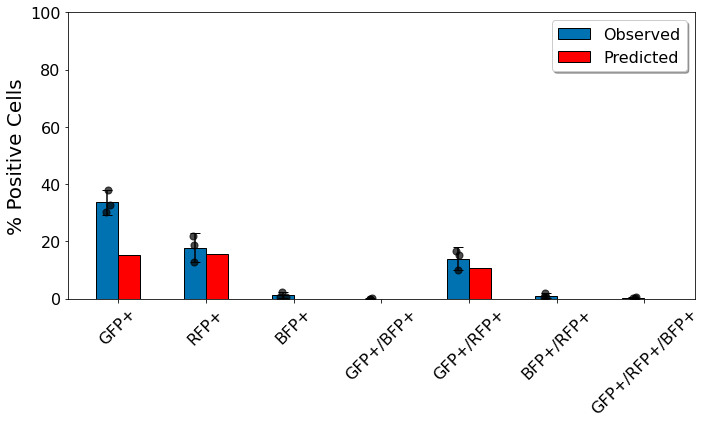

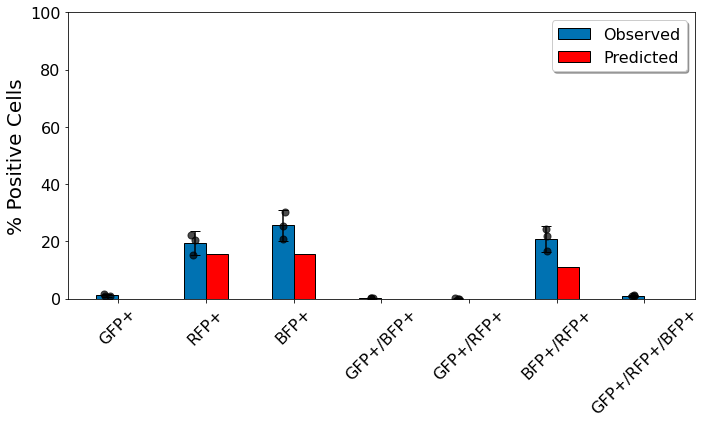

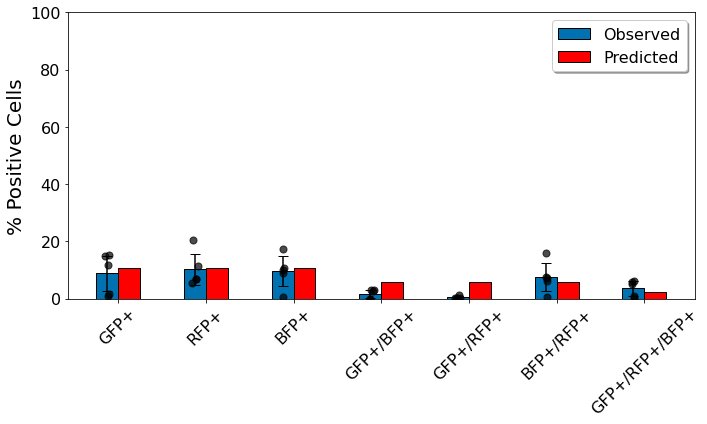

In [14]:
labels = ["GFP+", "RFP+", "BFP+", "GFP+/BFP+", "GFP+/RFP+", "BFP+/RFP+", "GFP+/RFP+/BFP+"]
x = np.arange(len(labels))
width = 0.25

for i in range(len(x0_list)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Bars
    ax.bar(x - width/2, data_pre_avg[i]* 100, width=width, yerr=data_pre_ci[i]* 100, color='#0072B2', edgecolor='black', label='Observed', capsize=5)
    ax.bar(x + width/2, model_2_preds[i]* 100, width=width, color='red', edgecolor='black', label='Predicted')
    
    # Scatter individual observations for the "Observed" data
    for j in range(len(x)):
        x_jitter = np.random.normal(loc=x[j] - width/2, scale=0.02, size=len(group_data_pre[i].iloc[:,j]))
        ax.scatter(x_jitter, group_data_pre[i].iloc[:,j]* 100, color='black', alpha=0.7, s=50, zorder=10)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, rotation=45)
    ax.set_ylabel('% Positive Cells', fontsize=20)
    #ax.set_xlabel('Marker', fontsize=20)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    #ax.set_title(f'Condition {i+1}', fontsize=22)
    ax.legend(loc='best', fontsize=16, frameon=True, shadow=True)
    
    plt.tight_layout()
    if i in [6]:
        plt.savefig(f"Figures/Fig4/Mod2_Pre/datavpreds_mod2_pre_{i}.svg")
    plt.savefig(f"Figures/FigS5/Mod2_Pre/datavpreds_mod2_pre_{i}.svg")
    plt.show()


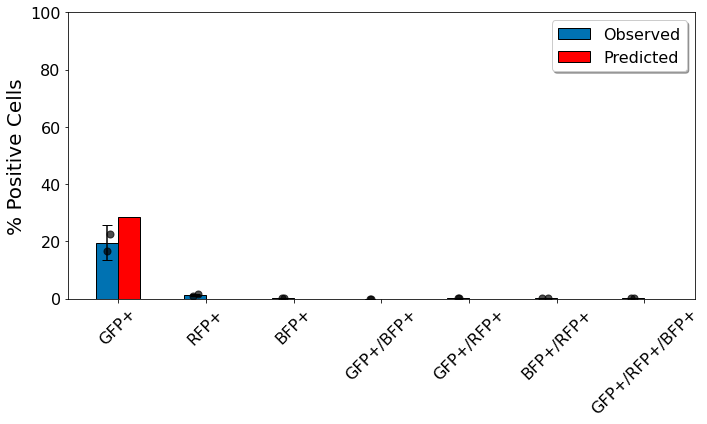

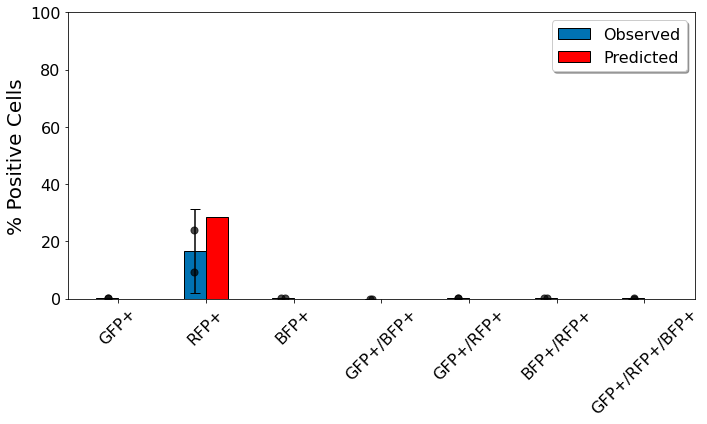

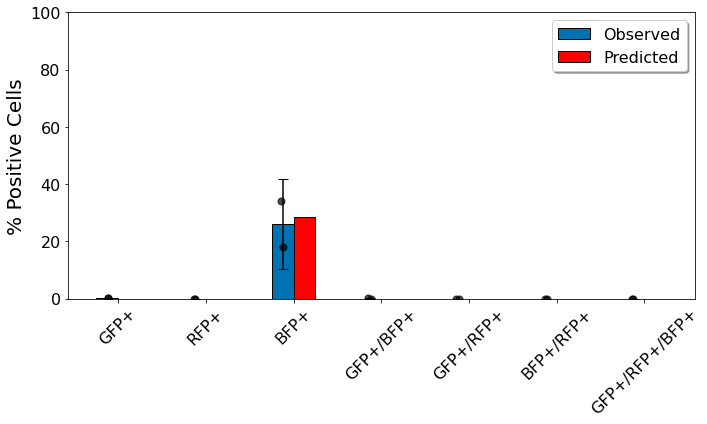

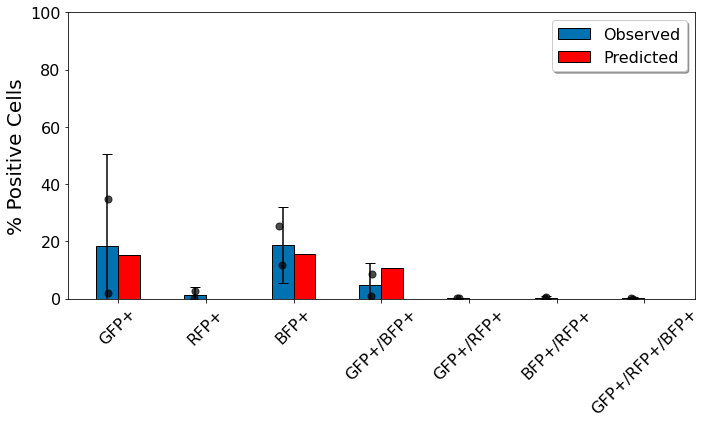

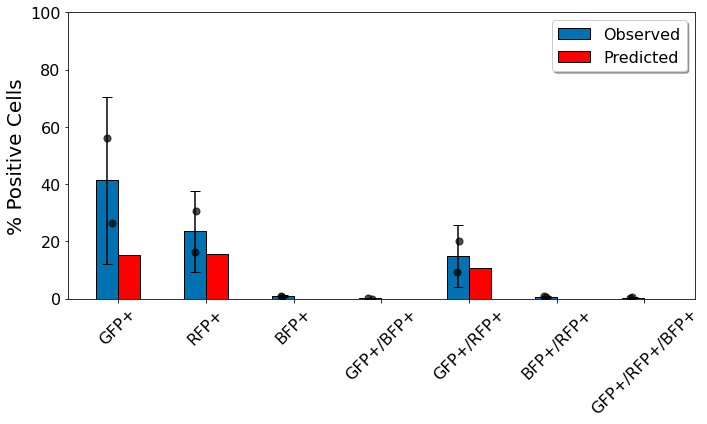

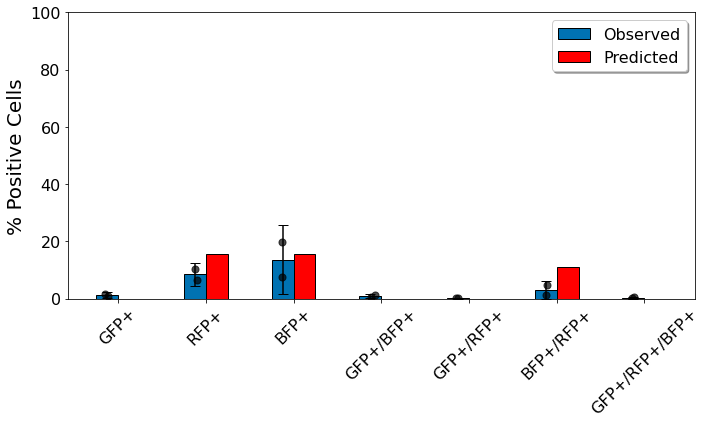

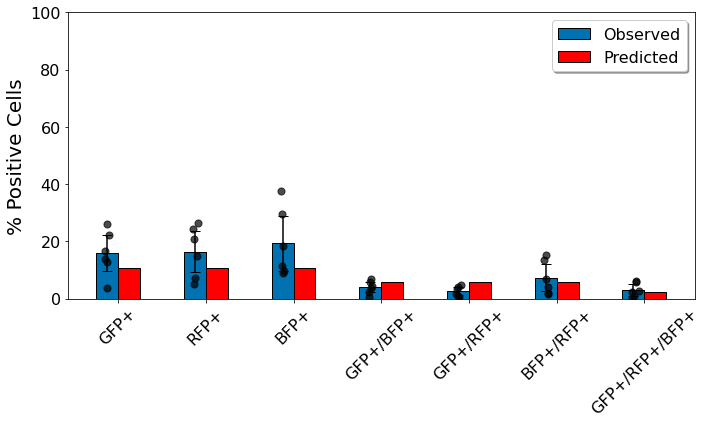

In [15]:
labels = ["GFP+", "RFP+", "BFP+", "GFP+/BFP+", "GFP+/RFP+", "BFP+/RFP+", "GFP+/RFP+/BFP+"]
x = np.arange(len(labels))
width = 0.25

for i in range(len(x0_list)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Bars
    ax.bar(x - width/2, data_post_avg[i]* 100, width=width, yerr=data_post_ci[i]* 100, color='#0072B2', edgecolor='black', label='Observed', capsize=5)
    ax.bar(x + width/2, model_2_preds[i]* 100, width=width, color='red', edgecolor='black', label='Predicted')
    
    # Scatter individual observations for the "Observed" data
    for j in range(len(x)):
        x_jitter = np.random.normal(loc=x[j] - width/2, scale=0.02, size=len(group_data_post[i].iloc[:,j]))
        ax.scatter(x_jitter, group_data_post[i].iloc[:,j]* 100, color='black', alpha=0.7, s=50, zorder=10)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, rotation=45)
    ax.set_ylabel('% Positive Cells', fontsize=20)
    #ax.set_xlabel('Marker', fontsize=20)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    #ax.set_title(f'Condition {i+1}', fontsize=22)
    ax.legend(loc='best', fontsize=16, frameon=True, shadow=True)
    
    plt.tight_layout()
    if i in [6]:
        plt.savefig(f"Figures/Fig4/Mod2_Post/datavpreds_mod2_post_{i}.svg")
    plt.savefig(f"Figures/FigS4/Mod2_Post/datavpreds_mod2_post_{i}.svg")
    plt.show()


In [16]:
ctrl_data = data[["pUC19" in x for x in data.index]].iloc[:,1:]
GFP_data = data[["GFP" in x and "RFP" not in x and "BFP" not in x for x in data.index]].iloc[:,1:]
RFP_data = data[["RFP" in x and "GFP" not in x and "BFP" not in x for x in data.index]].iloc[:,1:]
BFP_data = data[["BFP" in x and "GFP" not in x and "RFP" not in x for x in data.index]].iloc[:,1:]
GFP_BFP_postdata = data[["BFP" in x and "GFP" in x and "RFP" not in x and "POST" in x for x in data.index]].iloc[:,1:]
GFP_BFP_predata = data[["BFP" in x and "GFP" in x and "RFP" not in x and "POST" not in x for x in data.index]].iloc[:,1:]
GFP_RFP_postdata = data[["RFP" in x and "GFP" in x and "BFP" not in x and "POST" in x for x in data.index]].iloc[:,1:]
GFP_RFP_predata = data[["RFP" in x and "GFP" in x and "BFP" not in x and "POST" not in x for x in data.index]].iloc[:,1:]
BFP_RFP_postdata = data[["RFP" in x and "BFP" in x and "GFP" not in x and "POST" in x for x in data.index]].iloc[:,1:]
BFP_RFP_predata = data[["RFP" in x and "BFP" in x and "GFP" not in x and "POST" not in x for x in data.index]].iloc[:,1:]
all_postdata = data[["All" in x and "POST" in x for x in data.index]].iloc[:,1:]
all_predata = data[["All" in x  and "POST" not in x for x in data.index]].iloc[:,1:]




In [17]:
import scipy.stats
def log_likelihood_transfection_mod1(dataset, params):
    total_log_likelihood = 0
    eps = 1e-5

    for df in dataset:
        x0_list = df.iloc[:, -3:].to_numpy()     # Assume last 3 cols are G, R, B plasmid copy numbers
        obs_probs = df.iloc[:, 1:8].to_numpy()   # Assume columns 1–7 are GFP+, RFP+, etc
        n_cells_list = df.iloc[:, 0].to_numpy()  # First column = number of cells

        for x0_i, obs_i, n_cells_i in zip(x0_list, obs_probs, n_cells_list):
            x0_vec = np.array([[val, 0] for val in x0_i]).flatten()
            pred_probs = experiment_1(x0_vec, params)
            pred_probs = np.clip(pred_probs, eps, 1 - eps)
            k_obs = np.round(obs_i * n_cells_i).astype(int)
            expected_counts = pred_probs * n_cells_i
            # Poisson log likelihood for this condition
            total_log_likelihood += np.sum(scipy.stats.poisson.logpmf(k_obs, expected_counts))

    return total_log_likelihood


In [18]:

def log_likelihood_transfection_mod2(dataset, params):
    total_log_likelihood = 0
    eps = 1e-5

    for df in dataset:
        x0_list = df.iloc[:, -3:].to_numpy()     # Assume last 3 cols are G, R, B plasmid copy numbers
        obs_probs = df.iloc[:, 1:8].to_numpy()   # Assume columns 1–7 are GFP+, RFP+, etc
        n_cells_list = df.iloc[:, 0].to_numpy()  # First column = number of cells

        for x0_i, obs_i, n_cells_i in zip(x0_list, obs_probs, n_cells_list):
            x0_vec = np.array([[val, 0] for val in x0_i]).flatten()
            pred_probs = experiment_2(x0_vec, params)
            pred_probs = np.clip(pred_probs, eps, 1 - eps)
            k_obs = np.round(obs_i * n_cells_i).astype(int)
            expected_counts = pred_probs * n_cells_i
            total_log_likelihood += np.sum(scipy.stats.poisson.logpmf(k_obs, expected_counts))

    return total_log_likelihood


In [19]:
dataset_post = [ GFP_data, RFP_data, BFP_data,
            GFP_BFP_postdata, 
            GFP_RFP_postdata, 
            BFP_RFP_postdata,
            all_postdata]
print(log_likelihood_transfection_mod1(dataset_post, [estimate]))
print(log_likelihood_transfection_mod2(dataset_post, [estimate]))

-34885.94203348895
-26085.639688749834


In [20]:
dataset_pre = [ GFP_data, RFP_data, BFP_data,
            GFP_BFP_predata, 
            GFP_RFP_predata, 
            BFP_RFP_predata,
            all_predata]
print(log_likelihood_transfection_mod1(dataset_pre, [estimate]))
print(log_likelihood_transfection_mod2(dataset_pre, [estimate]))

-39769.859043950804
-24422.67212106968


In [21]:
dataset = dataset_pre
preplas2_pos2 = np.array(pd.concat([dataset[4].iloc[:,5], dataset[5].iloc[:,6], dataset[3].iloc[:,4]]))
preplas3_pos2 = np.array(pd.concat([dataset[6].iloc[:,5], dataset[6].iloc[:,6], dataset[6].iloc[:,4]]))
preplas3_pos3 = np.array(dataset[6].iloc[:,7])


In [22]:
dataset = dataset_post
postplas2_pos2 = np.array(pd.concat([dataset[4].iloc[:,5], dataset[5].iloc[:,6], dataset[3].iloc[:,4]]))
postplas3_pos2 = np.array(pd.concat([dataset[6].iloc[:,5], dataset[6].iloc[:,6], dataset[6].iloc[:,4]]))
postplas3_pos3 = np.array(dataset[6].iloc[:,7])



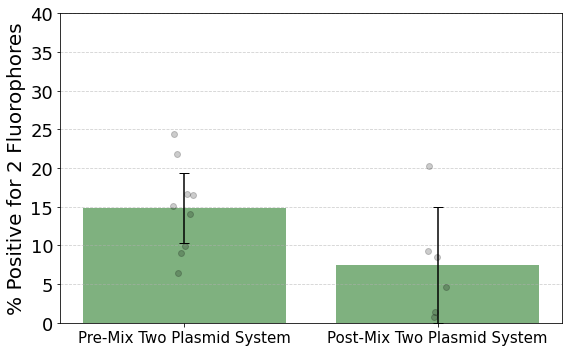

In [23]:
datasets = {
    "Pre-Mix Two Plasmid System": preplas2_pos2,
    "Post-Mix Two Plasmid System": postplas2_pos2
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)

# Plotting
x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))

# CI error bars
yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

# Plot bars with CI
ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

# Overlay raw data
for i, values in enumerate(raw_data):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)

ax.set_xticks(x)

ax.set_ylabel('% Positive for 2 Fluorophores', fontsize=20)
#ax.set_title('Means with 95% CI and Raw Data Overlay')
plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, 40)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()

plt.savefig(f"Figures/FigS1/plas2_vs2.svg")
plt.show()

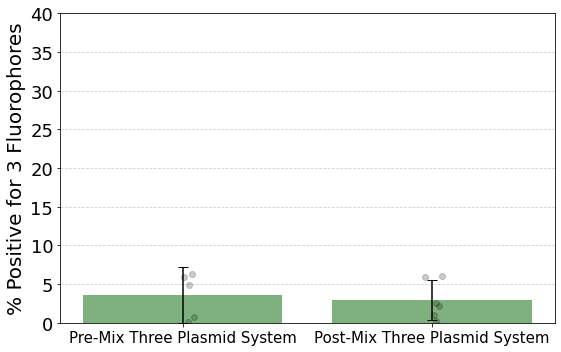

In [24]:
datasets = {

    "Pre-Mix Three Plasmid System": preplas3_pos3,
    "Post-Mix Three Plasmid System": postplas3_pos3
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)

# Plotting
x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))

# CI error bars
yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

# Plot bars with CI
ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

# Overlay raw data
for i, values in enumerate(raw_data):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)

ax.set_xticks(x)
ax.set_ylabel('% Positive for 3 Fluorophores', fontsize=20)
#ax.set_title('Means with 95% CI and Raw Data Overlay')
plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, 40)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()

plt.savefig(f"Figures/FigS1/plas3_vs3.svg")
plt.show()

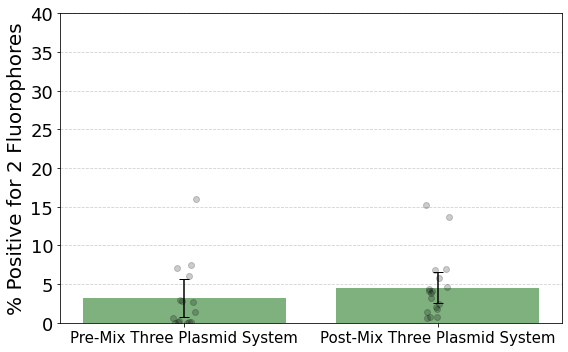

In [25]:
datasets = {
    "Pre-Mix Three Plasmid System": preplas3_pos2,
    "Post-Mix Three Plasmid System": postplas3_pos2,
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)

# Plotting
x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))

# CI error bars
yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

# Plot bars with CI
ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

# Overlay raw data
for i, values in enumerate(raw_data):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)

ax.set_xticks(x)
ax.set_ylabel('% Positive for 2 Fluorophores', fontsize=20)
#ax.set_title('Means with 95% CI and Raw Data Overlay')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
ax.set_ylim(0, 40)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()

plt.savefig(f"Figures/FigS1/plas3_vs2.svg")
plt.show()

In [36]:
u_stat, p_val = stats.mannwhitneyu(preplas2_pos2, postplas2_pos2, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 44.000, p = 0.04955045


In [38]:
u_stat, p_val = stats.mannwhitneyu(preplas3_pos2, postplas3_pos2, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 88.000, p = 0.09269465


In [39]:
u_stat, p_val = stats.mannwhitneyu(preplas3_pos3, postplas3_pos3, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 15.000, p = 1.00000000
